## TP de Machine Learning — Régression
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

---

Ce notebook implémente **3 algorithmes de Régression** :
1. Régression Linéaire Simple
2. Régression Linéaire Multiple
3. Régression Polynomiale

Chaque algorithme est comparé entre une implémentation **From Scratch** et **Scikit-Learn**.

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
%matplotlib inline

### IMPLÉMENTATION DE L'ÉQUATION NORMALE

In [2]:
class RegressionFromScratch:
    def __init__(self):
        self.theta = None

    def fit(self, X_train, y_train):
        # Ajouter une colonne de 1 pour le biais
        X_b = np.c_[np.ones((len(X_train), 1)), X_train]
        # Équation Normale : theta = (X^T * X)^-1 * X^T * y
        self.theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)

    def predict(self, X_test):
        X_b = np.c_[np.ones((len(X_test), 1)), X_test]
        return X_b.dot(self.theta)

### PRÉPARATION DES DONNÉES

In [3]:
df = pd.read_csv('data/medical_costs.csv')
X_simple = df[['age']].values
y = df[['cost']].values
X_multi = df[['age', 'bmi', 'children']].values
print(f"Nombre d'échantillons : {len(df)}")

Nombre d'échantillons : 500


### TEST 1 : RÉGRESSION LINÉAIRE SIMPLE

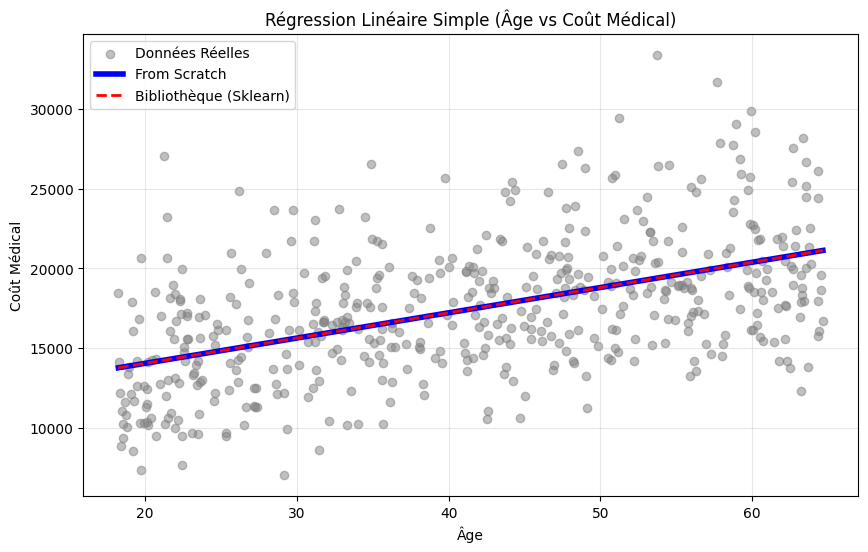

In [4]:
model_simple = RegressionFromScratch()
model_simple.fit(X_simple, y)
sk_simple = LinearRegression().fit(X_simple, y)
X_plot = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y, color='gray', alpha=0.5, label='Données Réelles')
plt.plot(X_plot, model_simple.predict(X_plot), color='blue', linewidth=4, label='From Scratch')
plt.plot(X_plot, sk_simple.predict(X_plot), color='red', linestyle='dashed', linewidth=2, label='Bibliothèque (Sklearn)')
plt.title('Régression Linéaire Simple (Âge vs Coût Médical)')
plt.xlabel('Âge'); plt.ylabel('Coût Médical')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

### TEST 2 : RÉGRESSION LINÉAIRE MULTIPLE

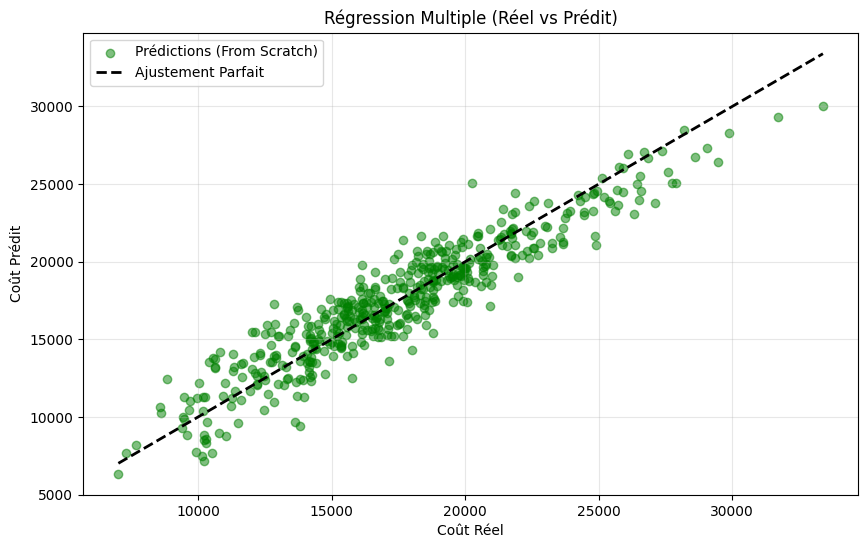

In [5]:
model_multi = RegressionFromScratch()
model_multi.fit(X_multi, y)
sk_multi = LinearRegression().fit(X_multi, y)
y_pred = model_multi.predict(X_multi)

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='green', alpha=0.5, label='Prédictions (From Scratch)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='dashed', lw=2, label='Ajustement Parfait')
plt.title('Régression Multiple (Réel vs Prédit)')
plt.xlabel('Coût Réel'); plt.ylabel('Coût Prédit')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

### TEST 3 : RÉGRESSION POLYNOMIALE

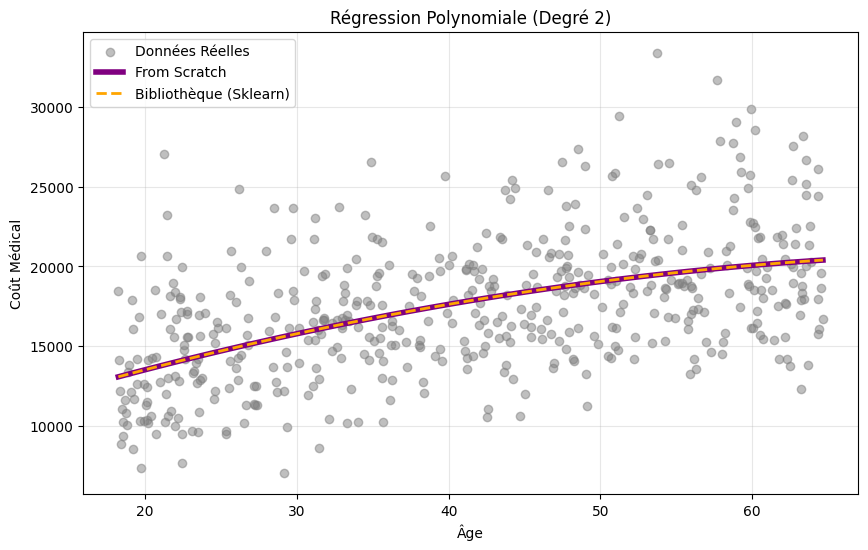

In [6]:
model_poly = RegressionFromScratch()
model_poly.fit(np.c_[X_simple, X_simple**2], y)
poly_feats = PolynomialFeatures(degree=2, include_bias=False)
sk_poly = LinearRegression().fit(poly_feats.fit_transform(X_simple), y)
X_pp = np.c_[X_plot, X_plot**2]

plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y, color='gray', alpha=0.5, label='Données Réelles')
plt.plot(X_plot, model_poly.predict(X_pp), color='purple', linewidth=4, label='From Scratch')
plt.plot(X_plot, sk_poly.predict(poly_feats.transform(X_plot)), color='orange', linestyle='dashed', linewidth=2, label='Bibliothèque (Sklearn)')
plt.title('Régression Polynomiale (Degré 2)')
plt.xlabel('Âge'); plt.ylabel('Coût Médical')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()